# ARTI404 - Image Processing
## Lab 4: Intensity Transformations and Filtering - Spatial Domain



### Step 0: Install packages and download the sample image (run once)

In [1]:
%pip install -q opencv-python numpy matplotlib scikit-image

import os

images_dir = os.path.join(os.getcwd(), 'images')
os.makedirs(images_dir, exist_ok=True)

url = 'https://raw.githubusercontent.com/PacktPublishing/Hands-On-Image-Processing-with-Python/master/images/parrot.png'
dest = os.path.join(images_dir, 'Parrot.png')

!curl -L -s -o "{dest}" "{url}"
size = os.path.getsize(dest) if os.path.exists(dest) else 0
print(f'Parrot.png: {"OK" if size > 0 else "FAILED"} ({size} bytes) -> {dest}')

Note: you may need to restart the kernel to use updated packages.
Parrot.png: OK (215272 bytes) -> c:\Users\dania\Image_Processing_Labs\Lab4\images\Parrot.png


## Task#1: Thresholding
Apply thresholding with a fixed threshold on an image.

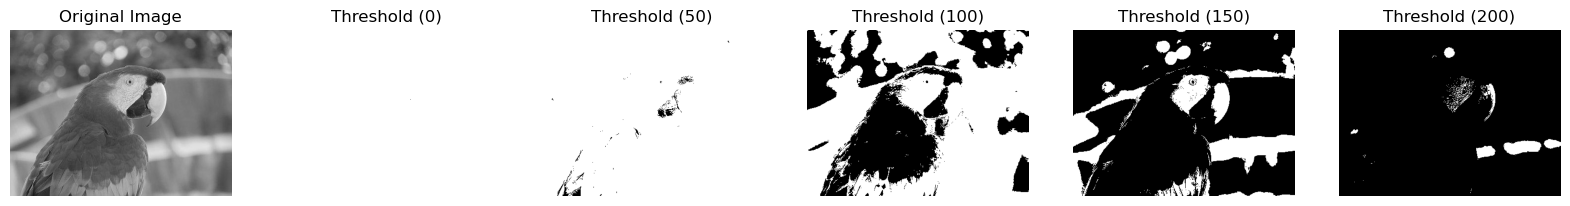

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread(os.path.join('images', 'Parrot.png'), cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values and display them all inline
fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(20, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for ax, threshold_value in zip(axes[1:], threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f'Threshold ({threshold_value})')
    ax.axis('off')

plt.show()

## Task#2: Histogram Processing

### Step#1: Load necessary libraries

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

### Step#2: Load moon image

In [4]:
img = data.moon()

### Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

In [5]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

### Step#4: Display the image with its histogram, for the original and the rescaled version

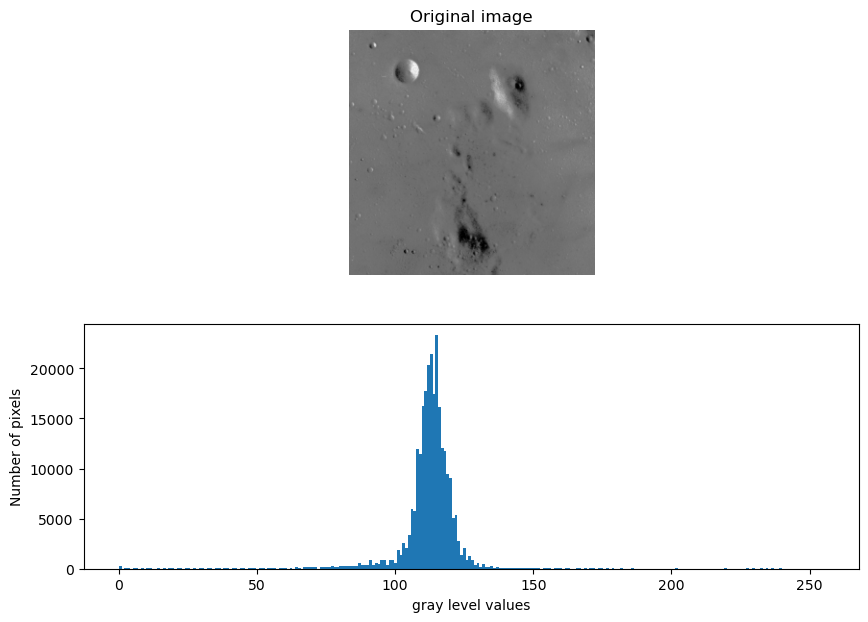

In [6]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

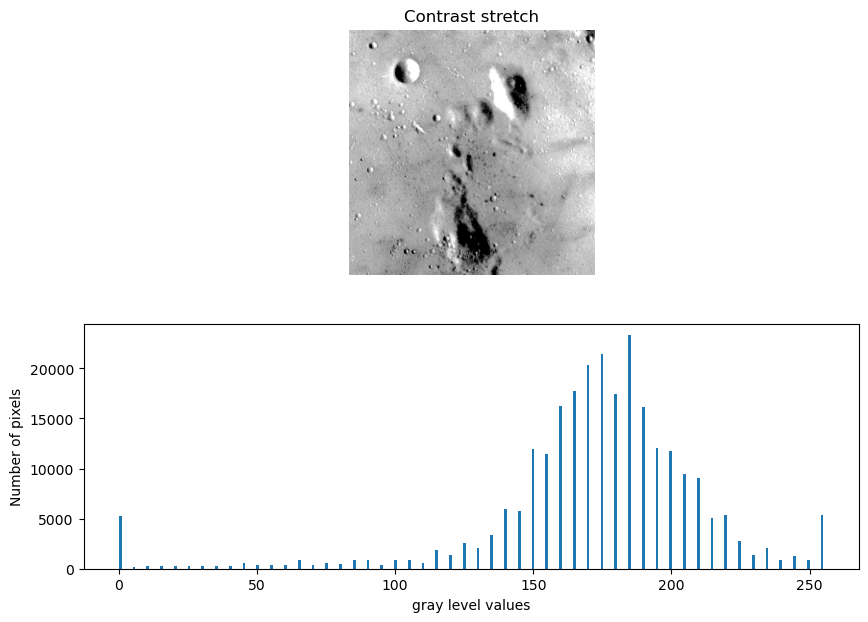

In [7]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

## Assessment

### Task#1: Rescale the moon image's intensities to the 3rd-80th percentile range and plot the histogram

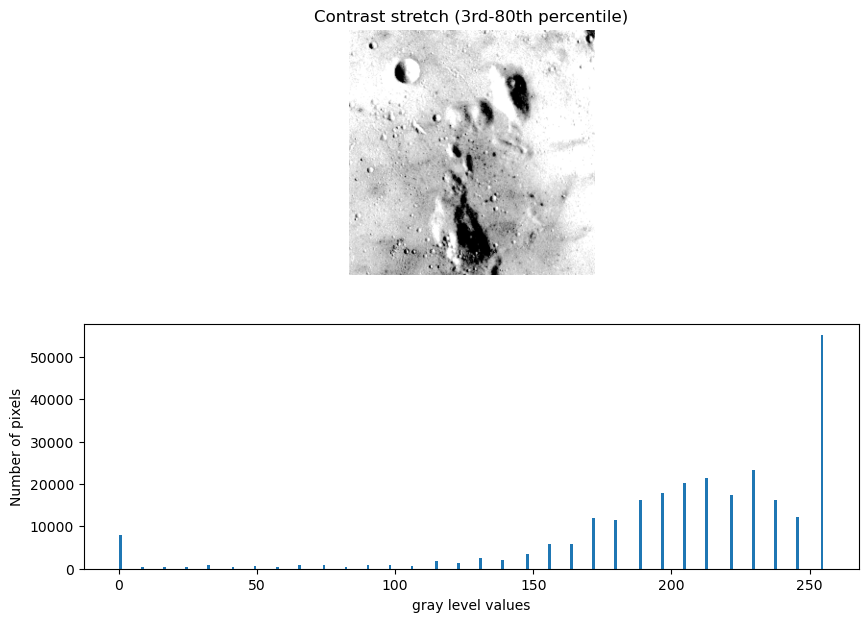

In [8]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task#2: Flatten (equalize) the moon image's histogram and display the result

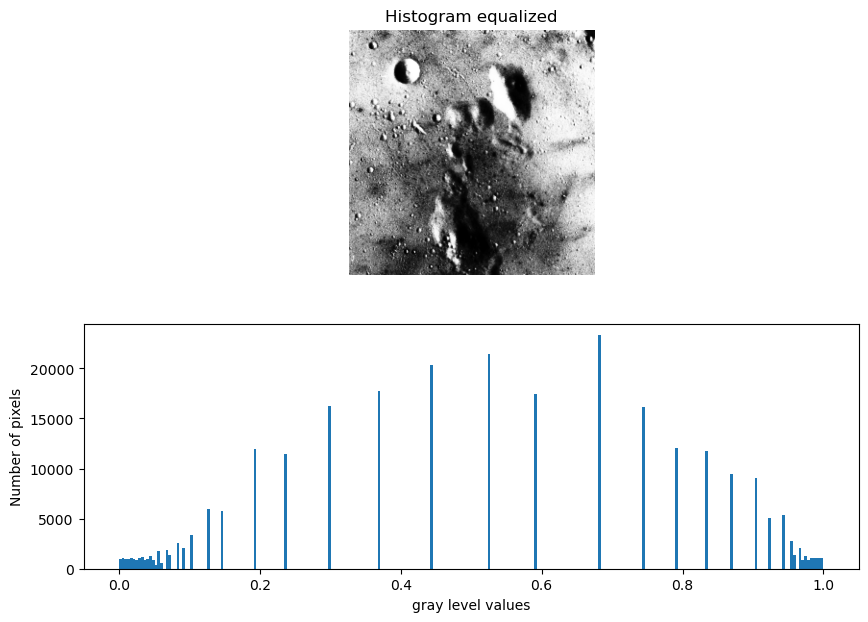

In [9]:
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task#3: Histogram matching using the rocket (reference) and Chelsea images

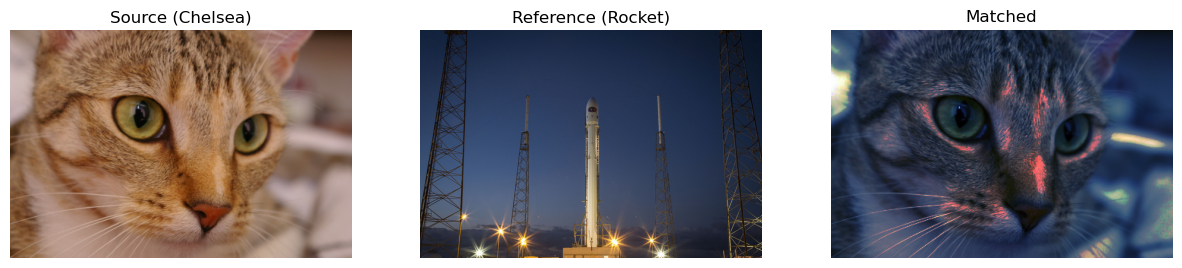

In [10]:
from skimage.exposure import match_histograms

reference = data.rocket()
source_img = data.chelsea()

matched = match_histograms(source_img, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(source_img); axes[0].set_title('Source (Chelsea)'); axes[0].axis('off')
axes[1].imshow(reference); axes[1].set_title('Reference (Rocket)'); axes[1].axis('off')
axes[2].imshow(matched.astype(np.uint8)); axes[2].set_title('Matched'); axes[2].axis('off')
plt.show()